# Analyse mechanism results

Read-only orchestrator over the result tables (Volt-VAr proxy, Volt-Watt proxy, response observability) via `result_views.py` and `result_plots.py`. 

In [1]:
from __future__ import annotations

import dataclasses
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

HERE = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in (HERE, *HERE.parents) if (p / 'src' / 'ausgrid_analysis').is_dir()), None)
assert PROJECT_ROOT is not None, 'Start Jupyter inside the ausgrid_analysis project.'
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from ausgrid_analysis.config import load_config
from ausgrid_analysis.mechanism_config import load_mechanism_config
from ausgrid_analysis import result_plots as rp
from ausgrid_analysis import result_views as rv

CONFIG_PATH = PROJECT_ROOT / 'analysis.toml'
config = load_config(CONFIG_PATH, check_inputs=True)
mechanism_der_inferred = load_mechanism_config(CONFIG_PATH)
mechanism_all_phases = dataclasses.replace(mechanism_der_inferred, phase_scope_basis='all_phases').validate()
mechanism_solar_proxy = dataclasses.replace(mechanism_der_inferred, capacity_basis='solar_capacity_kw_proxy').validate()
mechanism_p99_proxy = dataclasses.replace(mechanism_der_inferred, capacity_basis='p99_net_export_proxy').validate()
TRACKS = {
    'der_inferred': mechanism_der_inferred,
    'all_phases': mechanism_all_phases,
    'solar_capacity_kw_proxy': mechanism_solar_proxy,
    'p99_net_export_proxy': mechanism_p99_proxy,
}
pd.set_option('display.max_columns', 100)
plt.style.use('seaborn-v0_8-whitegrid')

## Stage 0: purpose, guardrails and source inventory

Lists every result file for both tracks (existence, size, row count, methodology id) and pulls the reconciled methodology/provenance context for each. 

`result_context` raises if a table's own methodology/provenance columns are internally mixed. 

The one expected cross-table difference `response_observability`'s methodology id not matching an `all_phases` curve-table run, because that table is never rebuilt per track. 
Is reported as an explicit flag rather than an error.

In [2]:
SAMPLE_MONTH = '2025-04'
SAMPLE_SITE_BUCKET = 0
sample_scope = config.scope(SAMPLE_MONTH, SAMPLE_SITE_BUCKET)
full_scope = config.scope(None, None)

contexts = {}
for track_name, mechanism in TRACKS.items():
    print(f'--- {track_name} ---')
    inventory = rv.result_inventory(config, full_scope, mechanism=mechanism)
    display(inventory)
    context = rv.result_context(config, full_scope, mechanism=mechanism)
    contexts[track_name] = context
    display(pd.Series(context, name='value').to_frame())
    assert context['formal_inverter_conformance_assessable'] is False, (
        f'{track_name}: formal_inverter_conformance_assessable must stay False -- '
        'this notebook never claims formal conformance.'
    )
    existing = inventory.loc[inventory['exists'], 'distinct_methodology_ids']
    assert (existing <= 1).all(), (
        f'{track_name}: a result file contains more than one methodology_id -- stop and investigate.'
    )

print()
print('response_observability_methodology_matches_curve_tables per track:')
for track_name, context in contexts.items():
    print(f"  {track_name}: {context['response_observability_methodology_matches_curve_tables']}")

--- der_inferred ---


,table,path,exists,size_bytes,modified_utc,row_count,distinct_methodology_ids,methodology_id
0,voltvar_proxy_results,C:\Users\z3553082\OneDrive - UNSW\Documents\CI...,True,1097895,2026-08-07T06:40:18.949558+00:00,125990,1,net_meter_proxy__voltage_avg__capacity_s_rated...
1,voltwatt_proxy_results,C:\Users\z3553082\OneDrive - UNSW\Documents\CI...,True,1069890,2026-08-07T06:40:28.550789+00:00,125990,1,net_meter_proxy__voltage_avg__capacity_s_rated...
2,response_observability,C:\Users\z3553082\OneDrive - UNSW\Documents\CI...,True,332212,2026-08-07T06:40:43.277950+00:00,32494,1,net_meter_proxy__voltage_avg__capacity_s_rated...


,value
measurement_basis,net_meter_proxy
voltage_measurement_location,revenue_meter
active_sign_review_state,empirically_supported_pending_provider_confirm...
formal_inverter_conformance_assessable,False
reactive_sign_review_state,empirically_supported_pending_provider_confirm...
voltage_basis,mean_inferred_der_phase_revenue_meter_voltage
capacity_basis,s_rated_kva
methodology_id,net_meter_proxy__voltage_avg__capacity_s_rated...
response_observability_methodology_id,net_meter_proxy__voltage_avg__capacity_s_rated...
response_observability_methodology_matches_curve_tables,True


--- all_phases ---


,table,path,exists,size_bytes,modified_utc,row_count,distinct_methodology_ids,methodology_id
0,voltvar_proxy_results,C:\Users\z3553082\OneDrive - UNSW\Documents\CI...,True,2054250,2026-08-07T06:41:26.924973+00:00,236277,1,net_meter_proxy__voltage_avg__phase_all_phases...
1,voltwatt_proxy_results,C:\Users\z3553082\OneDrive - UNSW\Documents\CI...,True,2022391,2026-08-07T06:41:40.396898+00:00,236277,1,net_meter_proxy__voltage_avg__phase_all_phases...
2,response_observability,C:\Users\z3553082\OneDrive - UNSW\Documents\CI...,True,332212,2026-08-07T06:40:43.277950+00:00,32494,1,net_meter_proxy__voltage_avg__capacity_s_rated...


...

,value
measurement_basis,net_meter_proxy
voltage_measurement_location,revenue_meter
active_sign_review_state,empirically_supported_pending_provider_confirm...
formal_inverter_conformance_assessable,False
reactive_sign_review_state,empirically_supported_pending_provider_confirm...
voltage_basis,mean_inferred_der_phase_revenue_meter_voltage
capacity_basis,solar_capacity_kw_proxy
methodology_id,net_meter_proxy__voltage_avg__capacity_solar_c...
response_observability_methodology_id,net_meter_proxy__voltage_avg__capacity_s_rated...
response_observability_methodology_matches_curve_tables,False


--- p99_net_export_proxy ---


,table,path,exists,size_bytes,modified_utc,row_count,distinct_methodology_ids,methodology_id
0,voltvar_proxy_results,C:\Users\z3553082\OneDrive - UNSW\Documents\CI...,True,1801487,2026-08-07T06:44:06.451717+00:00,125990,1,net_meter_proxy__voltage_avg__capacity_p99_net...
1,voltwatt_proxy_results,C:\Users\z3553082\OneDrive - UNSW\Documents\CI...,True,1079389,2026-08-07T06:44:17.887377+00:00,125990,1,net_meter_proxy__voltage_avg__capacity_p99_net...
2,response_observability,C:\Users\z3553082\OneDrive - UNSW\Documents\CI...,True,332212,2026-08-07T06:40:43.277950+00:00,32494,1,net_meter_proxy__voltage_avg__capacity_s_rated...


,value
measurement_basis,net_meter_proxy
voltage_measurement_location,revenue_meter
active_sign_review_state,empirically_supported_pending_provider_confirm...
formal_inverter_conformance_assessable,False
reactive_sign_review_state,empirically_supported_pending_provider_confirm...
voltage_basis,mean_inferred_der_phase_revenue_meter_voltage
capacity_basis,p99_net_export_proxy
methodology_id,net_meter_proxy__voltage_avg__capacity_p99_net...
response_observability_methodology_id,net_meter_proxy__voltage_avg__capacity_s_rated...
response_observability_methodology_matches_curve_tables,False



response_observability_methodology_matches_curve_tables per track:
  der_inferred: True
  all_phases: False
  solar_capacity_kw_proxy: False
  p99_net_export_proxy: False


## Stage 1: deterministic-slice validation

Same April 2025 / bucket 0 sample scope Notebook 4 uses. Loads the sample
mechanism outputs Notebook 4 already built and validates every
`result_views.py` view reconciles back to its own source file before any
plotting happens.

In [3]:
sample_validation = {}
for track_name, mechanism in TRACKS.items():
    result = rv.validate_result_views(config, sample_scope, mechanism=mechanism)
    sample_validation[track_name] = result
    headline = {k: v for k, v in result.items() if k not in {'failures', 'checks'}}
    display(pd.Series(headline, name='value').to_frame())
    if result['failures']:
        display(result['failures'])
    assert result['status'] == 'pass', f'{track_name}: sample view reconciliation failed -- see failures above.'
print('Deterministic-slice view reconciliation passed for both tracks.')

,value
status,pass
scope,month_2025_04__bucket_0_of_32
phase_scope_basis,der_inferred


,value
status,pass
scope,month_2025_04__bucket_0_of_32
phase_scope_basis,all_phases


,value
status,pass
scope,month_2025_04__bucket_0_of_32
phase_scope_basis,der_inferred


,value
status,pass
scope,month_2025_04__bucket_0_of_32
phase_scope_basis,der_inferred


Deterministic-slice view reconciliation passed for both tracks.


## Stage 2: Volt-VAr denominator coverage (deterministic slice)

Sequential denominator precedence: a source interval is classified as the
first of `ineligible_site`, `missing_input`, `not_activated`,
`sign_unverified`, `capacity_unavailable`, `below_minimum_active_power` that
applies, else `assessable`. Every fraction below is of `n_source_intervals`.

C:\Users\z3553082\AppData\Local\Temp\ipykernel_50944\1630688543.py:8: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


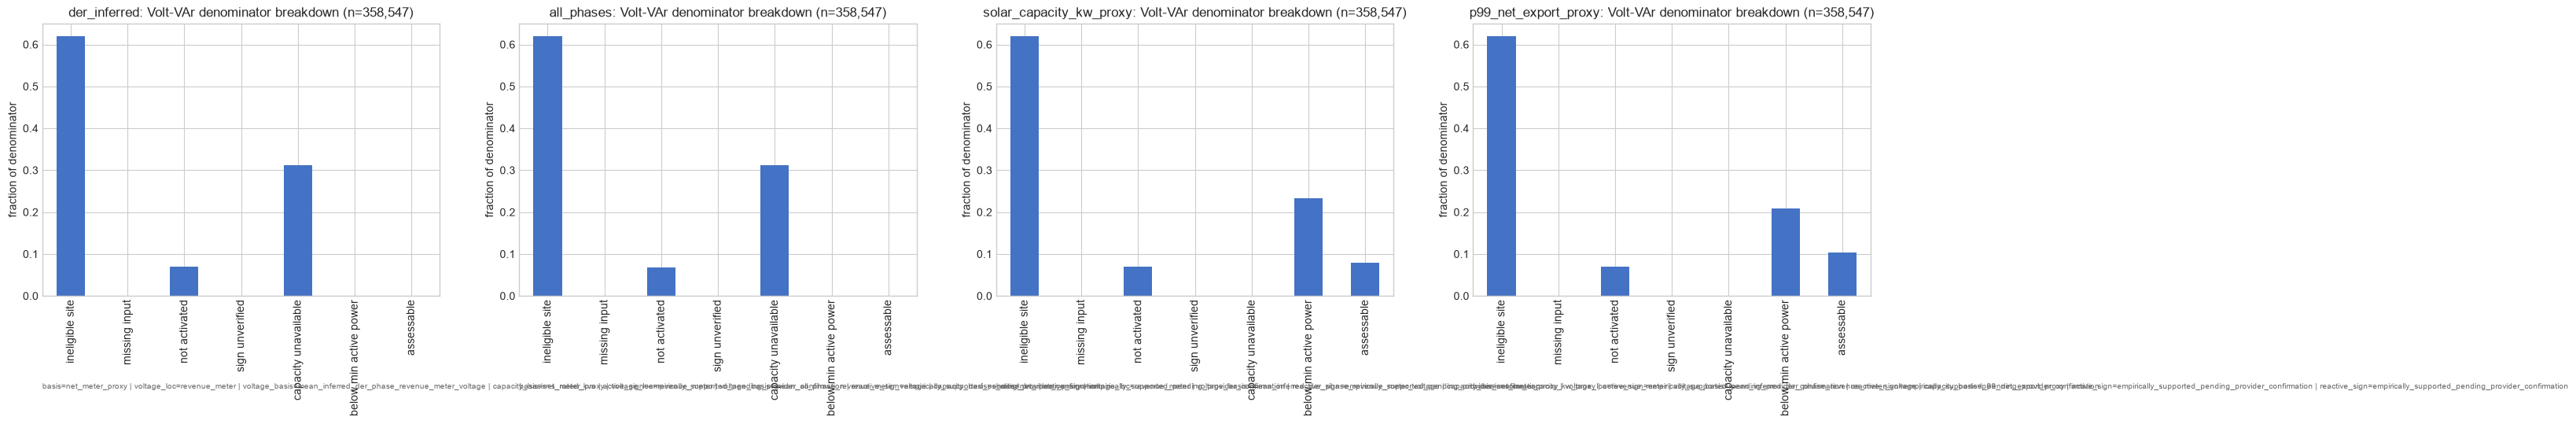

In [4]:
fig, axes = plt.subplots(1, len(TRACKS), figsize=(7.5 * len(TRACKS), 4.5))
sample_voltvar_denominator = {}
for ax, (track_name, mechanism) in zip(axes, TRACKS.items()):
    frame = rv.voltvar_denominator_view(config, sample_scope, mechanism=mechanism)
    sample_voltvar_denominator[track_name] = frame
    rp.plot_denominator_breakdown(frame, mechanism_name='Volt-VAr', context=contexts[track_name], ax=ax)
    ax.set_title(f'{track_name}: ' + ax.get_title())
plt.tight_layout()
plt.show()

## Stage 3: Volt-VAr proxy statuses (deterministic slice)

Only meaningful if `n_assessable > 0`. With `s_rated_kva` unavailable for
every site today, `n_assessable` is expected to be 0 -- the panel below
shows that honestly rather than reporting a 0% conformance rate.

der_inferred: n_assessable = 0
all_phases: n_assessable = 0
solar_capacity_kw_proxy: n_assessable = 28,113
p99_net_export_proxy: n_assessable = 36,988


C:\Users\z3553082\AppData\Local\Temp\ipykernel_50944\408893800.py:10: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


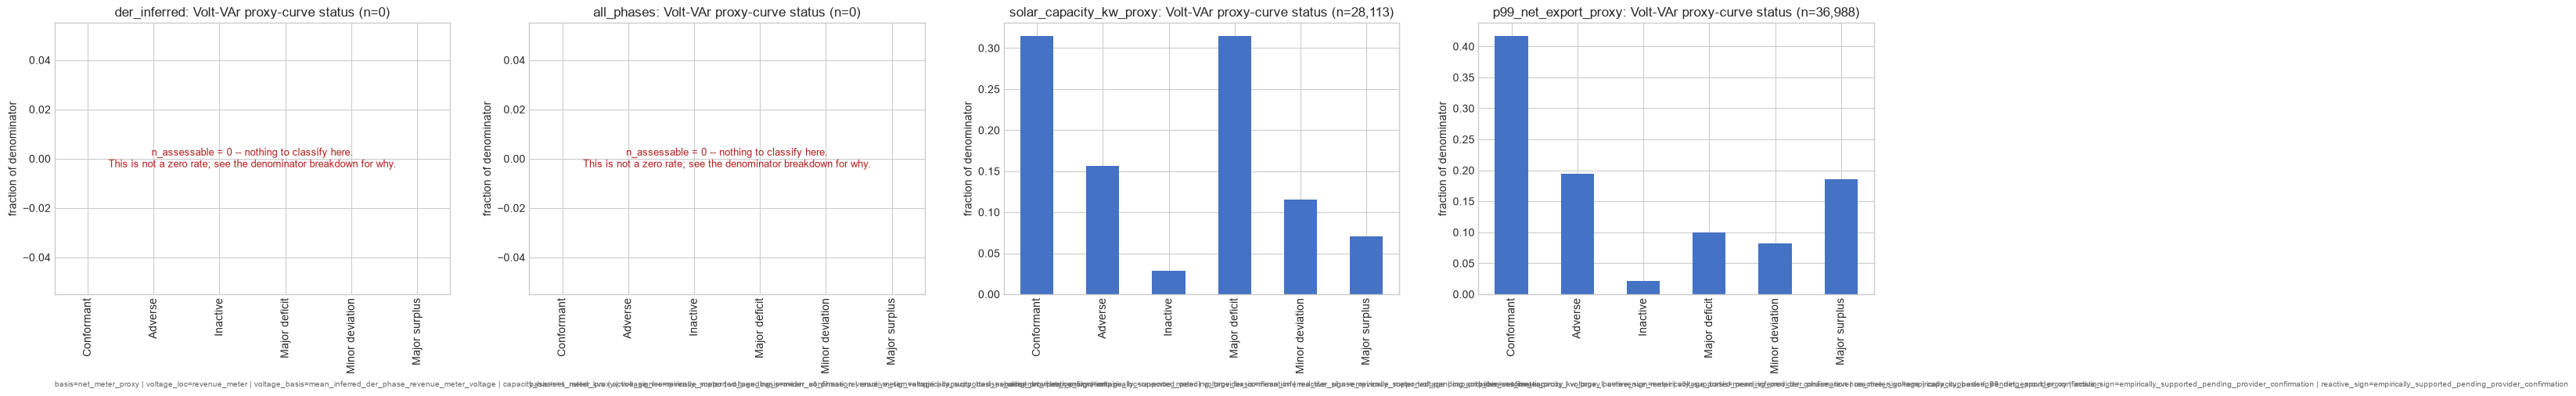

In [5]:
fig, axes = plt.subplots(1, len(TRACKS), figsize=(7.5 * len(TRACKS), 4.5))
sample_voltvar_status = {}
for ax, (track_name, mechanism) in zip(axes, TRACKS.items()):
    frame = rv.voltvar_status_view(config, sample_scope, mechanism=mechanism, minimum_denominator=30)
    sample_voltvar_status[track_name] = frame
    rp.plot_status_breakdown(frame, mechanism_name='Volt-VAr', context=contexts[track_name], ax=ax)
    ax.set_title(f'{track_name}: ' + ax.get_title())
    n_assessable = int(frame['n_assessable'].iloc[0])
    print(f'{track_name}: n_assessable = {n_assessable:,}')
plt.tight_layout()
plt.show()

## Stage 4: Volt-Watt denominator coverage (deterministic slice)

`not_activated` (voltage at or below V1) and `not_exporting` (net export
`<= 0`) are different filters: a site can be exporting but below the
Volt-Watt activation voltage, or above it but net-importing at that instant.

C:\Users\z3553082\AppData\Local\Temp\ipykernel_50944\2834690987.py:8: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


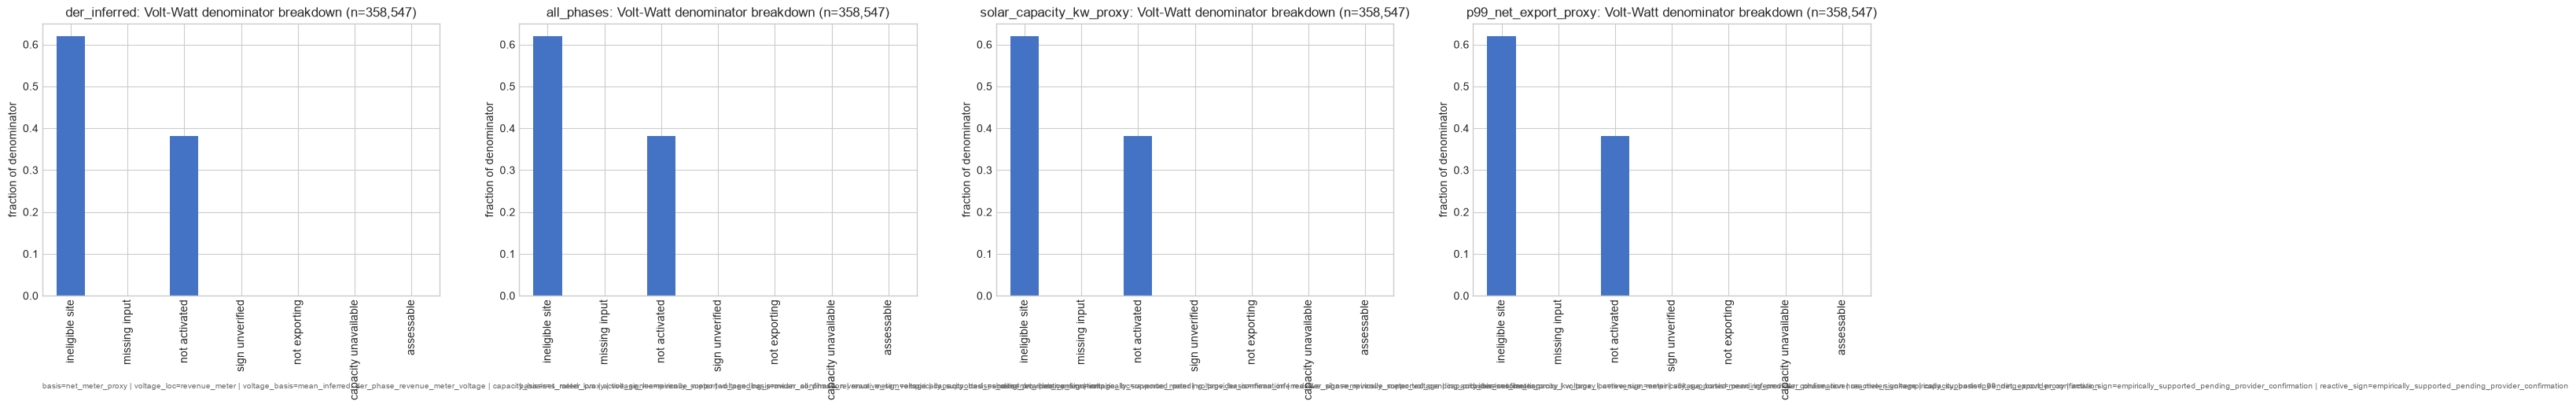

In [6]:
fig, axes = plt.subplots(1, len(TRACKS), figsize=(7.5 * len(TRACKS), 4.5))
sample_voltwatt_denominator = {}
for ax, (track_name, mechanism) in zip(axes, TRACKS.items()):
    frame = rv.voltwatt_denominator_view(config, sample_scope, mechanism=mechanism)
    sample_voltwatt_denominator[track_name] = frame
    rp.plot_denominator_breakdown(frame, mechanism_name='Volt-Watt', context=contexts[track_name], ax=ax)
    ax.set_title(f'{track_name}: ' + ax.get_title())
plt.tight_layout()
plt.show()

## Stage 5: Volt-Watt proxy statuses (deterministic slice)

`proxy_does_not_exceed_curve_ceiling` is never conformance evidence --
household load can suppress net export below the ceiling regardless of
inverter behaviour.

der_inferred: n_assessable = 0
all_phases: n_assessable = 0
solar_capacity_kw_proxy: n_assessable = 0
p99_net_export_proxy: n_assessable = 0


C:\Users\z3553082\AppData\Local\Temp\ipykernel_50944\3254204159.py:10: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


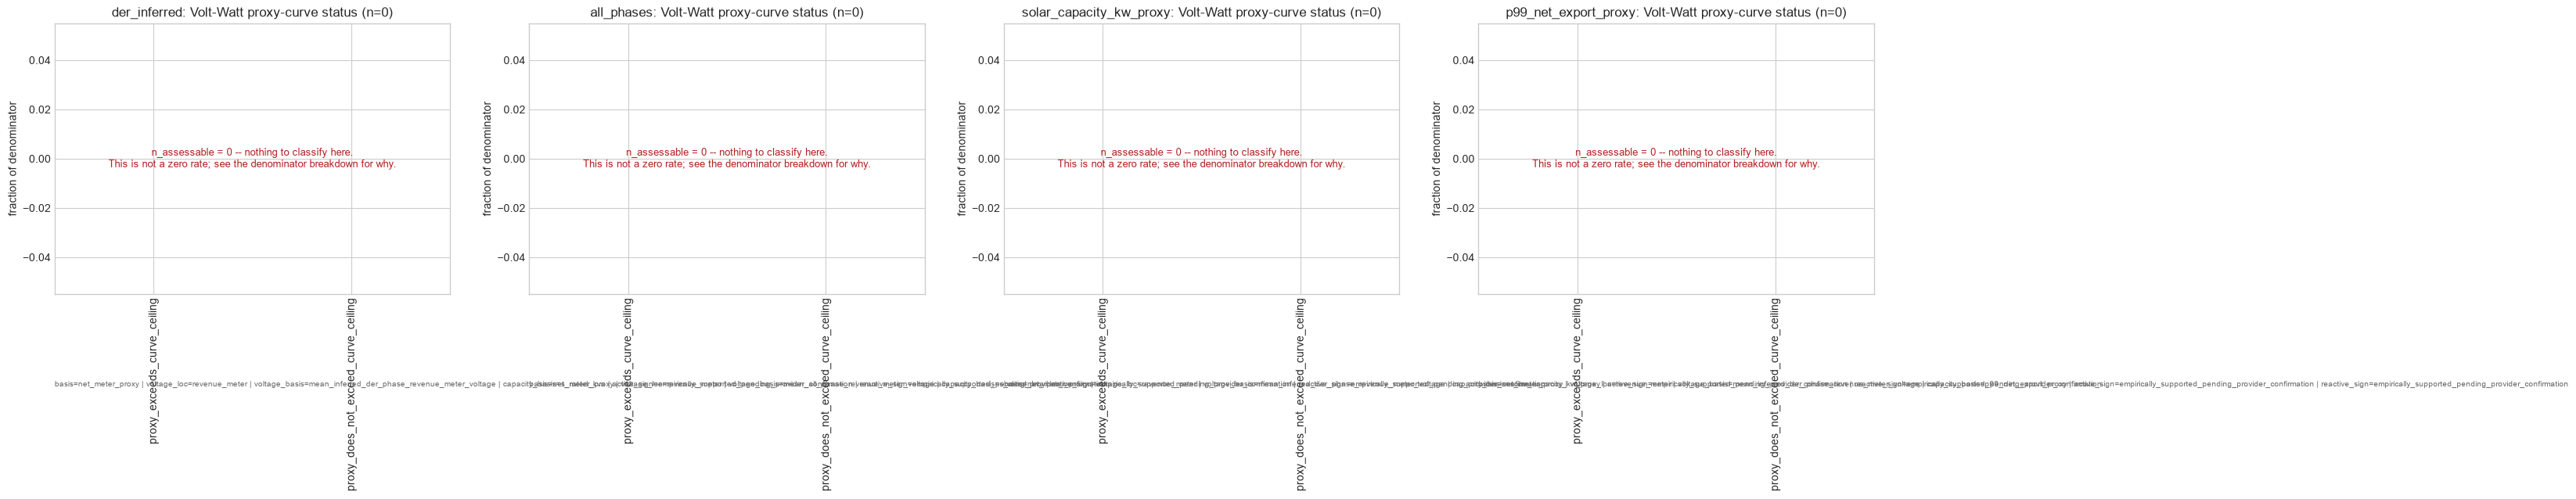

In [7]:
fig, axes = plt.subplots(1, len(TRACKS), figsize=(7.5 * len(TRACKS), 4.5))
sample_voltwatt_status = {}
for ax, (track_name, mechanism) in zip(axes, TRACKS.items()):
    frame = rv.voltwatt_status_view(config, sample_scope, mechanism=mechanism)
    sample_voltwatt_status[track_name] = frame
    rp.plot_status_breakdown(frame, mechanism_name='Volt-Watt', context=contexts[track_name], ax=ax)
    ax.set_title(f'{track_name}: ' + ax.get_title())
    n_assessable = int(frame['n_assessable'].iloc[0])
    print(f'{track_name}: n_assessable = {n_assessable:,}')
plt.tight_layout()
plt.show()

## Stage 6: response observability (deterministic slice)

Volt-VAr and Volt-Watt observability are shown separately below; both
remain association/direction evidence only, never a causal or conformance
claim. `response_observability.parquet` is the single shared table -- it is
identical for both tracks (see the Stage 0 methodology check above), so it
is read once, using `mechanism_der_inferred` only for its review-state
labels.

,0
n_site_phase_months,89
n_voltvar_status_ineligible_site,42.0
n_voltvar_status_not_inferred_der_phase,13.0
n_voltvar_status_sign_unverified,0.0
n_voltvar_status_insufficient_excitation,4.0
n_voltvar_status_expected_direction_observed,22.0
n_voltvar_status_opposite_or_flat_direction_observed,8.0
n_voltwatt_status_ineligible_site,42.0
n_voltwatt_status_not_inferred_der_phase,13.0
n_voltwatt_status_sign_unverified,0.0


C:\Users\z3553082\AppData\Local\Temp\ipykernel_50944\3407070594.py:7: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


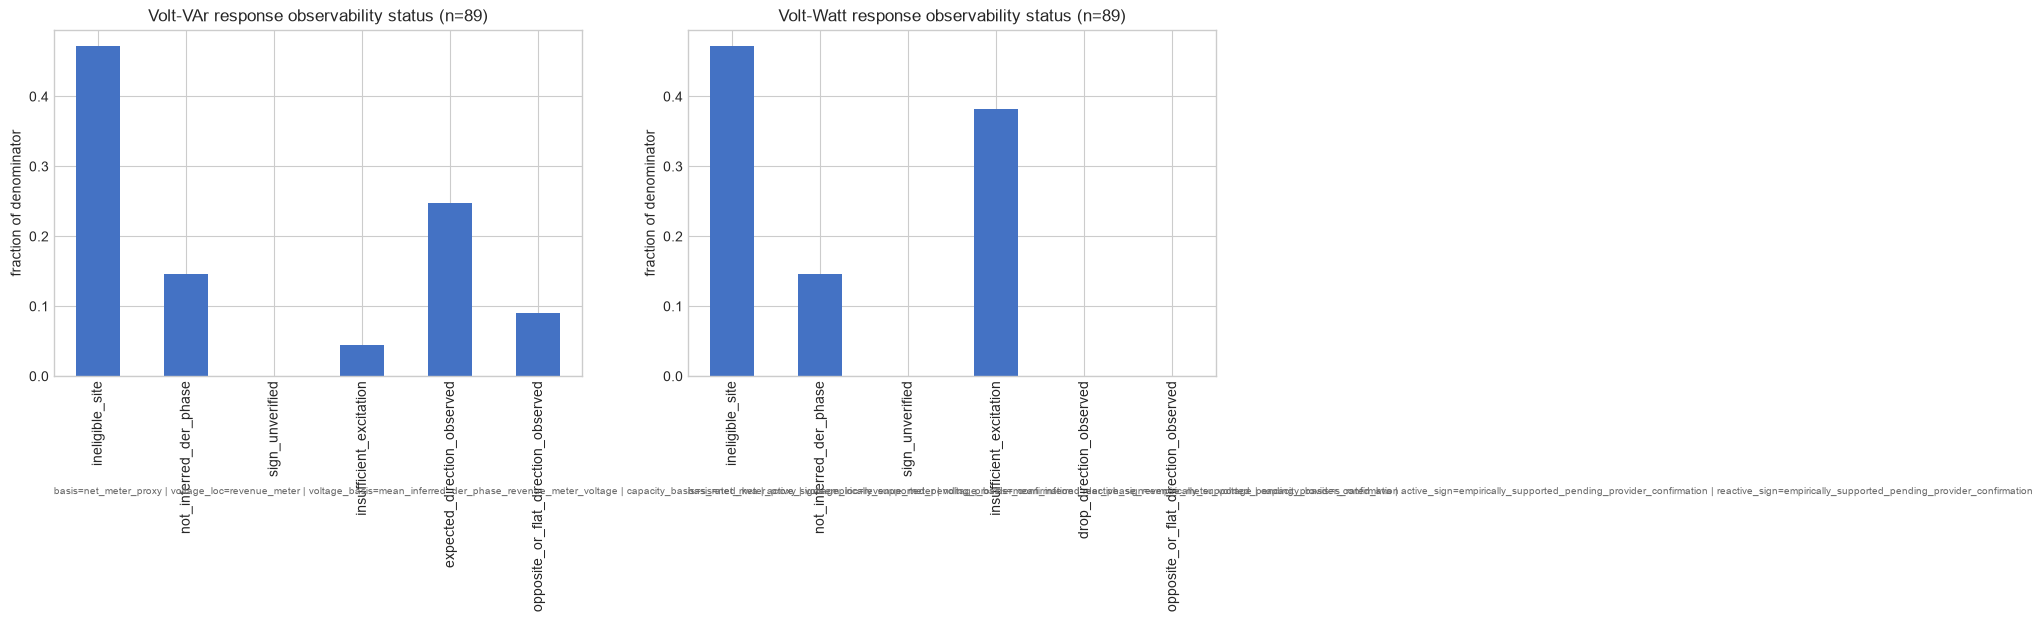

,0
n_voltvar_excited_intervals,236106.0
voltvar_slope_var_per_v_weighted_mean,-36.537097
voltvar_voltage_correlation_mean,-0.201918
voltvar_voltage_span_v_mean,8.043835
voltvar_minimum_voltage_v,240.009918
voltvar_maximum_voltage_v,252.985931
n_voltwatt_excited_export_intervals,0.0
voltwatt_slope_w_per_v_weighted_mean,NaN
voltwatt_voltage_correlation_mean,NaN
voltwatt_voltage_span_v_mean,NaN


In [8]:
sample_observability_status = rv.observability_status_view(config, sample_scope, mechanism=mechanism_der_inferred)
display(sample_observability_status.T)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
rp.plot_observability_status(sample_observability_status, mechanism_name='Volt-VAr', context=contexts['der_inferred'], ax=axes[0])
rp.plot_observability_status(sample_observability_status, mechanism_name='Volt-Watt', context=contexts['der_inferred'], ax=axes[1])
plt.tight_layout()
plt.show()

sample_observability_metric = rv.observability_metric_view(
    config, sample_scope, mechanism=mechanism_der_inferred,
    minimum_excited_intervals=mechanism_der_inferred.minimum_response_intervals,
)
display(sample_observability_metric.T)

## Stage 7: sample gate

Re-asserts, for both tracks, that every view reconciles, dimensions are
valid, classifications never exceed their own denominator, and provenance is
internally consistent, before unlocking the full-results stages below.

In [9]:
for track_name, mechanism in TRACKS.items():
    result = rv.validate_result_views(config, sample_scope, mechanism=mechanism)
    assert result['status'] == 'pass', f"{track_name}: sample gate failed -- {result['failures']}"
    context = rv.result_context(config, sample_scope, mechanism=mechanism)
    assert context['formal_inverter_conformance_assessable'] is False
for track_name, frame in sample_voltvar_status.items():
    classified = sum(int(frame[c].iloc[0]) for c in rv.VOLTVAR_STATUS_COLUMNS)
    assert classified == int(frame['n_assessable'].iloc[0]), f'{track_name}: Volt-VAr classification exceeds n_assessable'
for track_name, frame in sample_voltwatt_status.items():
    classified = sum(int(frame[c].iloc[0]) for c in rv.VOLTWATT_STATUS_COLUMNS)
    assert classified == int(frame['n_assessable'].iloc[0]), f'{track_name}: Volt-Watt classification exceeds n_assessable'
print('Sample gate passed for both tracks -- proceeding to full-results analysis is safe.')

Sample gate passed for both tracks -- proceeding to full-results analysis is safe.


## Stage 8: deliberate full-results analysis

The remaining stages read the full Notebook 4 outputs (not a sample). They
are still read-only -- no `build_*` call appears below -- but can be
computationally heavier, so they stay behind an explicit, deliberate opt-in
per the acceptance spec, mirroring Notebook 4's own full-run gate.

In [10]:
FULL_ANALYSIS_CONFIRMATION = 'RUN FULL RESULTS ANALYSIS'  # Change to: RUN FULL RESULTS ANALYSIS
for _name in TRACKS:
    assert sample_validation[_name]['status'] == 'pass', f'{_name}: sample validation not passing'
assert FULL_ANALYSIS_CONFIRMATION == 'RUN FULL RESULTS ANALYSIS', (
    "Review Stages 0-7 above, then set FULL_ANALYSIS_CONFIRMATION = 'RUN FULL RESULTS ANALYSIS'."
)
print('Full-results analysis unlocked:', full_scope.label)

Full-results analysis unlocked: full


## Stage 9: fleet summary and Volt-VAr classification (full dataset)

Kept deliberately simple -- more detailed breakdowns (by month, cohort,
voltage bin) can be added back once this baseline is validated.

**Eligibility, confirmed:** every row in every track below is already
restricted to `analysis_cohort = 'solar_only'` and `controlled_load = 'No'`
sites (plus no battery, high-confidence phase mapping, full power
coverage) -- this is `core_site_gate_sql` in `mechanism_results.py`, applied
unconditionally to every track, not something this notebook filters again.

**Fleet KPI table:** sites/timestamps analysed, sites/timestamps that
crossed the mechanism's activation threshold ("required a response"), and
-- Volt-VAr only -- timestamps where a response was actually observed.
Volt-Watt has no analogous "had a response" figure: being below the
Volt-Watt ceiling is not evidence of curtailment (no counterfactual P
exists to compare against), so that column is `NaN` rather than fabricated.

**Volt-VAr classification:** `Q_impact = sign x (Q_kvar / Q_voltvar)`,
where `Q_voltvar` is the nearest edge of the tolerance-clamped required
band and `sign` is +1 when measured Q points the same direction as that
edge, else -1 (see `q_impact_nearest_edge_sql`). Every assessable interval
falls into exactly one of six buckets -- each count is a count of
timestamps (source intervals), not sites:

| Bucket | Meaning |
|---|---|
| Conformant | measured Q falls inside the tolerance-clamped required band itself |
| Adverse | Q_impact < -10% (wrong direction) |
| Inactive | -10% to +10% (no meaningful response) |
| Major deficit | +10% to +90% (some response, not enough) |
| Minor deviation | +90% to +110% (close to required, outside the exact band) |
| Major surplus | > +110% (more than required) |

**Conformance rollup (reviewed methodology):** a business-rule grouping on
top of the six buckets above, not a new measurement --
`non-conformance = Adverse + Inactive + Major deficit`,
`conformance = Conformant + Minor deviation + Major surplus`. Shown at both
the timestamp level (fraction of assessable intervals) and the site level
(is *this site's own majority* of assessable intervals conformant -- default
threshold 50%, see `voltvar_site_conformance_view`). A site with zero
assessable intervals is reported separately as `not_assessable`, never
folded into non-conformant.

In [11]:
fleet_summary = pd.DataFrame(
    [
        rv.fleet_summary_view(config, full_scope, mechanism_name=mechanism_name, mechanism=mechanism)
        for mechanism_name in ('Volt-VAr', 'Volt-Watt')
        for track_name, mechanism in TRACKS.items()
    ]
)
fleet_summary.insert(1, 'track', [t for _ in ('Volt-VAr', 'Volt-Watt') for t in TRACKS])
fleet_summary = fleet_summary.set_index(['mechanism', 'track'])
display(fleet_summary)

n_sites_analyzed  n_timestamps_analyzed  \
mechanism track                                                              
Volt-VAr  der_inferred                          410               42858638   
          all_phases                            410               42858638   
          solar_capacity_kw_proxy               410               42858638   
          p99_net_export_proxy                  410               42858638   
Volt-Watt der_inferred                          410               42858638   
          all_phases                            410               42858638   
          solar_capacity_kw_proxy               410               42858638   
          p99_net_export_proxy                  410               42858638   

                                   n_sites_requiring_response  \
mechanism track                                                 
Volt-VAr  der_inferred                                    410   
          all_phases                                      409   
          solar_capacity_kw_proxy                         410   
          p99_net_export_proxy                            410   
Volt-Watt der_inferred                                     64   
          all_phases                                       37   
          solar_capacity_kw_proxy                          64   
          p99_net_export_proxy                             64   

                                   n_timestamps_requiring_response  \
mechanism track                                                      
Volt-VAr  der_inferred                                    34001843   
          all_phases                                      33707589   
          solar_capacity_kw_proxy                         34001843   
          p99_net_export_proxy                            34001843   
Volt-Watt der_inferred                                       50738   
          all_phases                                          8767   
          solar_capacity_kw_proxy                            50738   
          p99_net_export_proxy                               50738   

                                   n_timestamps_with_response  \
mechanism track                                                 
Volt-VAr  der_inferred                                    0.0   
          all_phases                                      0.0   
          solar_capacity_kw_proxy                   9118221.0   
          p99_net_export_proxy                     11644850.0   
Volt-Watt der_inferred                                    NaN   
          all_phases                                      NaN   
          solar_capacity_kw_proxy                         NaN   
          p99_net_export_proxy                            NaN   

                                   pct_timestamps_with_response  
mechanism track                                                  
Volt-VAr  der_inferred                                     0.00  
          all_phases                                       0.00  
          solar_capacity_kw_proxy                         26.82  
          p99_net_export_proxy                            34.25  
Volt-Watt der_inferred                                      NaN  
          all_phases                                        NaN  
          solar_capacity_kw_proxy                           NaN  
          p99_net_export_proxy                              NaN

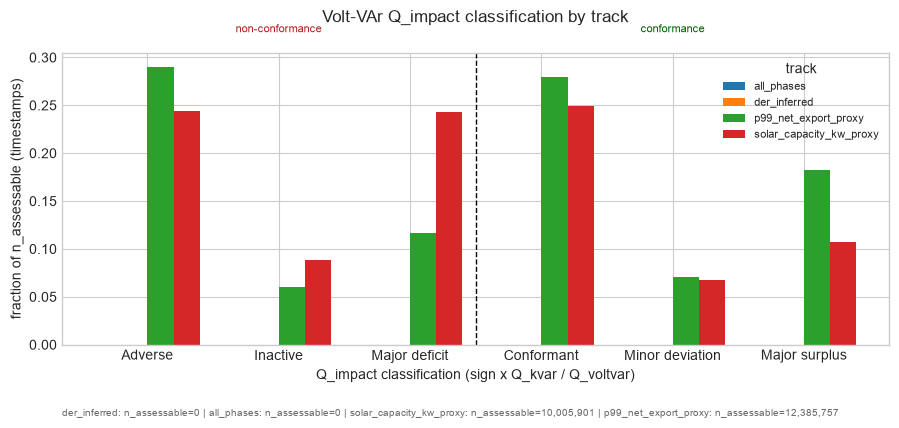

Raw timestamp counts per bucket (not fractions):


track,all_phases,der_inferred,p99_net_export_proxy,solar_capacity_kw_proxy
bucket,,,,
Adverse,0,0,3597105,2436959
Inactive,0,0,740907,887680
Major deficit,0,0,1447897,2433414
Conformant,0,0,3461367,2497215
Minor deviation,0,0,880550,676164
Major surplus,0,0,2257931,1074469


In [12]:
full_voltvar_status = {
    track_name: rv.voltvar_status_view(config, full_scope, mechanism=mechanism)
    for track_name, mechanism in TRACKS.items()
}
rp.plot_voltvar_classification_by_track(full_voltvar_status)
plt.tight_layout()
plt.show()

print('Raw timestamp counts per bucket (not fractions):')
display(rp.voltvar_classification_counts_by_track(full_voltvar_status))

### Conformance rollup -- timestamp level and site level

In [13]:
conformance_timestamp_level = pd.DataFrame(
    {
        track_name: {
            'n_assessable': int(frame['n_assessable'].iloc[0]),
            'n_conformance': int(frame['n_conformance'].iloc[0]),
            'n_non_conformance': int(frame['n_non_conformance'].iloc[0]),
            'conformance_fraction': frame['conformance_fraction_of_assessable'].iloc[0],
        }
        for track_name, frame in full_voltvar_status.items()
    }
).T
display(conformance_timestamp_level)

,n_assessable,n_conformance,n_non_conformance,conformance_fraction
der_inferred,0,0,0,<NA>
all_phases,0,0,0,<NA>
solar_capacity_kw_proxy,10005901.0,4247848.0,5758053.0,0.424534
p99_net_export_proxy,12385757.0,6599848.0,5785909.0,0.532858


In [32]:
site_conformance = {
    track_name: rv.voltvar_site_conformance_view(config, full_scope, mechanism=mechanism)
    for track_name, mechanism in TRACKS.items()
}
site_conformance_counts = pd.DataFrame(
    {track_name: frame['site_status'].value_counts() for track_name, frame in site_conformance.items()}
).fillna(0).astype(int)
display(site_conformance_counts)

,der_inferred,all_phases,solar_capacity_kw_proxy,p99_net_export_proxy
site_status,,,,
conformant,0,0,170,236
non_conformant,0,0,240,174
not_assessable,1342,1342,932,932


In [34]:
sc = site_conformance['p99_net_export_proxy']
sc.to_csv('sites_breakdown_p99_net_export_proxy.csv')
sc

,serial,n_assessable,n_conformant,n_adverse,n_inactive,n_major_deficit,n_minor_deviation,n_major_surplus,n_conformance,n_non_conformance,conformance_fraction,non_conformance_fraction,site_status,conformance_threshold
0,326214487,32295.0,30303.0,9.0,1.0,118.0,1461.0,403.0,32167.0,128.0,0.996037,0.003963,conformant,0.5
1,326214520,11386.0,2637.0,4.0,2.0,2.0,326.0,8415.0,11378.0,8.0,0.999297,0.000703,conformant,0.5
2,326228801,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,<NA>,<NA>,not_assessable,0.5
3,326612333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,<NA>,<NA>,not_assessable,0.5
4,361431370,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,<NA>,<NA>,not_assessable,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1337,811411119,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,<NA>,<NA>,not_assessable,0.5
1338,811411139,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,<NA>,<NA>,not_assessable,0.5
1339,811420217,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,<NA>,<NA>,not_assessable,0.5
1340,811486456,6509.0,1435.0,1290.0,119.0,362.0,126.0,3177.0,4738.0,1771.0,0.727915,0.272085,conformant,0.5


### Volt-Watt curve status by track

Volt-Watt has only two statuses -- exceeds the ceiling or does not.
`proxy_does_not_exceed_curve_ceiling` is never relabelled conformance:
household load can suppress net export below the ceiling regardless of
inverter behaviour, so there is no equivalent conformance rollup here.

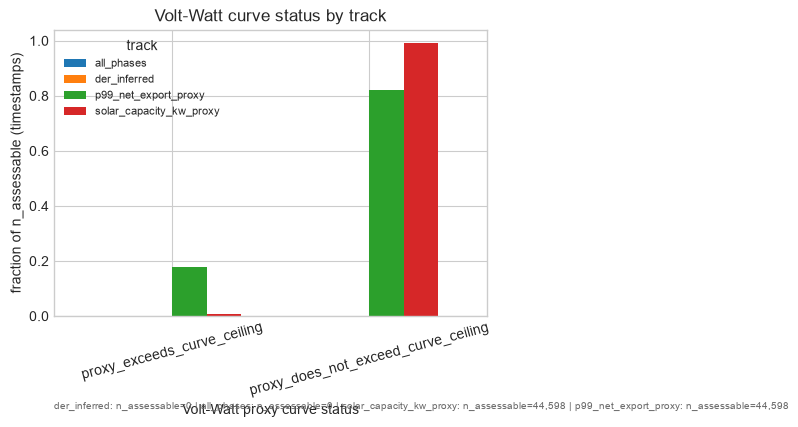

In [15]:
full_voltwatt_status = {
    track_name: rv.voltwatt_status_view(config, full_scope, mechanism=mechanism)
    for track_name, mechanism in TRACKS.items()
}
rp.plot_voltwatt_classification_by_track(full_voltwatt_status)
plt.tight_layout()
plt.show()

In [16]:
full_observability_by_month = rv.observability_status_view(
    config, full_scope, mechanism=mechanism_der_inferred, dimensions=('year_utc', 'month_utc')
)
display(full_observability_by_month[['year_utc', 'month_utc', 'n_site_phase_months']])

full_observability_by_cohort = rv.observability_status_view(
    config, full_scope, mechanism=mechanism_der_inferred, dimensions=('analysis_cohort',)
)
display(full_observability_by_cohort)

,year_utc,month_utc,n_site_phase_months
0,2024,8,2691
1,2024,9,2691
2,2024,10,2714
3,2024,11,2714
4,2024,12,2714
5,2025,1,2710
6,2025,2,2710
7,2025,3,2710
8,2025,4,2710
9,2025,5,2710


,analysis_cohort,n_site_phase_months,n_voltvar_status_ineligible_site,n_voltvar_status_not_inferred_der_phase,n_voltvar_status_sign_unverified,n_voltvar_status_insufficient_excitation,n_voltvar_status_expected_direction_observed,n_voltvar_status_opposite_or_flat_direction_observed,n_voltwatt_status_ineligible_site,n_voltwatt_status_not_inferred_der_phase,n_voltwatt_status_sign_unverified,n_voltwatt_status_insufficient_excitation,n_voltwatt_status_drop_direction_observed,n_voltwatt_status_opposite_or_flat_direction_observed,voltvar_status_ineligible_site_fraction_of_site_phase_months,voltvar_status_not_inferred_der_phase_fraction_of_site_phase_months,voltvar_status_sign_unverified_fraction_of_site_phase_months,voltvar_status_insufficient_excitation_fraction_of_site_phase_months,voltvar_status_expected_direction_observed_fraction_of_site_phase_months,voltvar_status_opposite_or_flat_direction_observed_fraction_of_site_phase_months,voltwatt_status_ineligible_site_fraction_of_site_phase_months,voltwatt_status_not_inferred_der_phase_fraction_of_site_phase_months,voltwatt_status_sign_unverified_fraction_of_site_phase_months,voltwatt_status_insufficient_excitation_fraction_of_site_phase_months,voltwatt_status_drop_direction_observed_fraction_of_site_phase_months,voltwatt_status_opposite_or_flat_direction_observed_fraction_of_site_phase_months,active_sign_review_state,reactive_sign_review_state
0,solar_battery,8835,8835.0,0.0,0.0,0.0,0.0,0.0,8835.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,empirically_supported_pending_provider_confirm...,empirically_supported_pending_provider_confirm...
1,solar_only,21775,7270.0,4344.0,0.0,566.0,6272.0,3323.0,7270.0,4344.0,0.0,10103.0,32.0,26.0,0.333869,0.199495,0.0,0.025993,0.288037,0.152606,0.333869,0.199495,0.0,0.463972,0.00147,0.001194,empirically_supported_pending_provider_confirm...,empirically_supported_pending_provider_confirm...
2,NaN,1884,1884.0,0.0,0.0,0.0,0.0,0.0,1884.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,empirically_supported_pending_provider_confirm...,empirically_supported_pending_provider_confirm...


## Stage 10: site and phase explorer

Set `SELECTED_SERIAL` and `SELECTED_PHASE` to inspect a specific site or
phase. Both use aggregated views only -- no per-interval telemetry is ever
loaded into pandas here. Denominator and methodology context are shown next
to each panel so an unassessable site is never mistaken for a
poor-performing one.

Selected serial: 810584444


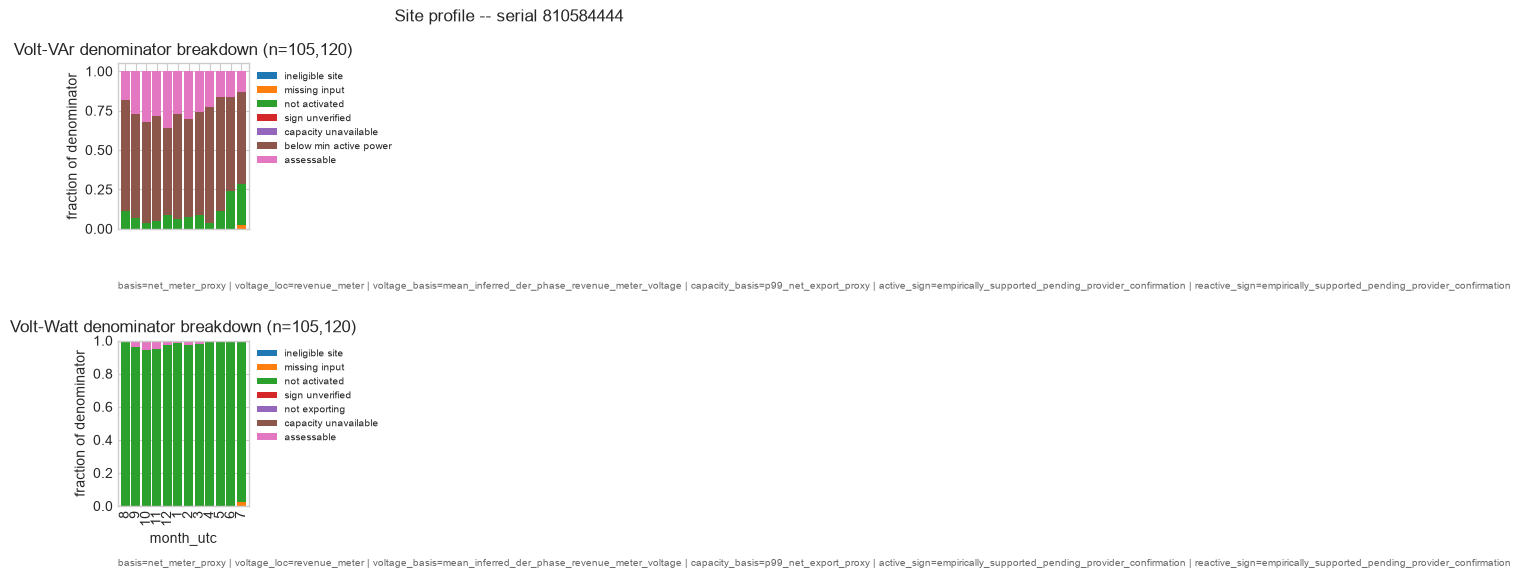

In [17]:
per_site_month_p99_vv = rv.voltvar_denominator_view(
    config, full_scope, mechanism=mechanism_p99_proxy, dimensions=('serial', 'year_utc', 'month_utc')
)
per_site_month_p99_vw = rv.voltwatt_denominator_view(
    config, full_scope, mechanism=mechanism_p99_proxy, dimensions=('serial', 'year_utc', 'month_utc')
)

SELECTED_SERIAL = '810584444'  # SITE_A_SERIAL or SITE_B_SERIAL
print('Selected serial:', SELECTED_SERIAL)

fig = rp.plot_site_profile(per_site_month_p99_vv, per_site_month_p99_vw, SELECTED_SERIAL, context=contexts['p99_net_export_proxy'])
plt.show()

In [18]:
SELECTED_PHASE = 'A'  # edit to 'A', 'B' or 'C'

observability_by_phase = rv.observability_status_view(config, full_scope, mechanism=mechanism_der_inferred, dimensions=('phase',))
display(observability_by_phase)

observability_metric_by_phase = rv.observability_metric_view(config, full_scope, mechanism=mechanism_der_inferred, dimensions=('phase',))
display(observability_metric_by_phase[observability_metric_by_phase['phase'] == SELECTED_PHASE])

,phase,n_site_phase_months,n_voltvar_status_ineligible_site,n_voltvar_status_not_inferred_der_phase,n_voltvar_status_sign_unverified,n_voltvar_status_insufficient_excitation,n_voltvar_status_expected_direction_observed,n_voltvar_status_opposite_or_flat_direction_observed,n_voltwatt_status_ineligible_site,n_voltwatt_status_not_inferred_der_phase,n_voltwatt_status_sign_unverified,n_voltwatt_status_insufficient_excitation,n_voltwatt_status_drop_direction_observed,n_voltwatt_status_opposite_or_flat_direction_observed,voltvar_status_ineligible_site_fraction_of_site_phase_months,voltvar_status_not_inferred_der_phase_fraction_of_site_phase_months,voltvar_status_sign_unverified_fraction_of_site_phase_months,voltvar_status_insufficient_excitation_fraction_of_site_phase_months,voltvar_status_expected_direction_observed_fraction_of_site_phase_months,voltvar_status_opposite_or_flat_direction_observed_fraction_of_site_phase_months,voltwatt_status_ineligible_site_fraction_of_site_phase_months,voltwatt_status_not_inferred_der_phase_fraction_of_site_phase_months,voltwatt_status_sign_unverified_fraction_of_site_phase_months,voltwatt_status_insufficient_excitation_fraction_of_site_phase_months,voltwatt_status_drop_direction_observed_fraction_of_site_phase_months,voltwatt_status_opposite_or_flat_direction_observed_fraction_of_site_phase_months,active_sign_review_state,reactive_sign_review_state
0,A,16020,11121.0,1320.0,0.0,167.0,2367.0,1045.0,11121.0,1320.0,0.0,3543.0,19.0,17.0,0.694195,0.082397,0.0,0.010424,0.147753,0.065231,0.694195,0.082397,0.0,0.221161,0.001186,0.001061,empirically_supported_pending_provider_confirm...,empirically_supported_pending_provider_confirm...
1,B,8686,3787.0,1620.0,0.0,203.0,1897.0,1179.0,3787.0,1620.0,0.0,3264.0,9.0,6.0,0.435989,0.186507,0.0,0.023371,0.218397,0.135736,0.435989,0.186507,0.0,0.375777,0.001036,0.000691,empirically_supported_pending_provider_confirm...,empirically_supported_pending_provider_confirm...
2,C,7788,3081.0,1404.0,0.0,196.0,2008.0,1099.0,3081.0,1404.0,0.0,3296.0,4.0,3.0,0.395609,0.180277,0.0,0.025167,0.257833,0.141115,0.395609,0.180277,0.0,0.423215,0.000514,0.000385,empirically_supported_pending_provider_confirm...,empirically_supported_pending_provider_confirm...


,phase,n_voltvar_excited_intervals,voltvar_slope_var_per_v_weighted_mean,voltvar_voltage_correlation_mean,voltvar_voltage_span_v_mean,voltvar_minimum_voltage_v,voltvar_maximum_voltage_v,n_voltwatt_excited_export_intervals,voltwatt_slope_w_per_v_weighted_mean,voltwatt_voltage_correlation_mean,voltwatt_voltage_span_v_mean,voltwatt_minimum_voltage_v,voltwatt_maximum_voltage_v,voltvar_low_denominator_warning,voltwatt_low_denominator_warning,active_sign_review_state,reactive_sign_review_state
0,A,24712246.0,-54.202187,-0.226369,8.885779,240.009918,261.705322,45453.0,-20.037253,-0.008349,1.349001,253.006546,259.74707,False,False,empirically_supported_pending_provider_confirm...,empirically_supported_pending_provider_confirm...


## Stage 11: curtailment status

Only the explicit unavailable-gate-7 panel is rendered. No curtailment
energy, frequency, rate or blended score is computed anywhere in this
notebook.

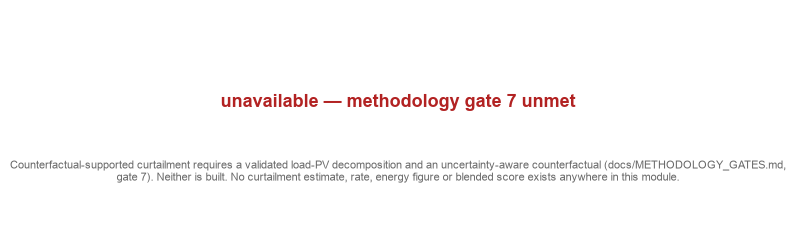

In [19]:
rp.plot_curtailment_unavailable()
plt.show()

## Stage 12 — final interpretation checklist

**Structurally validated** (Stages 0, 1, 7): both `phase_scope_basis`
tracks' Volt-VAr and Volt-Watt result files carry a single, internally
consistent `methodology_id`; every fleet-level `result_views.py` aggregate
reconciles exactly to its own source parquet; classification counts never
exceed their own `n_assessable`; `response_observability` is confirmed
identical across both tracks (it is the one shared, unnamespaced table).

**Observable** (Stage 6, 9): response-observability status and
slope/correlation evidence exist for both mechanisms, but every
`*_observability_status` row is currently `sign_unverified` (or
`ineligible_site` / `not_inferred_der_phase`) because
`active_sign_review_state` and `reactive_sign_review_state` remain
`unverified` in `analysis.toml`. This is association/direction evidence
only -- never a causal or conformance claim -- and it stays that way
regardless of `phase_scope_basis`, since the sign gate is a fleet-wide
config choice, not a phase-scope one.

**Unassessable** (Stages 2-5, 9): `n_assessable` is 0 for both Volt-VAr and
Volt-Watt, on both tracks, across the entire fleet, because verified
`s_rated_kva` is null for every site in this metadata extract. No magnitude
proxy-curve status has ever been computed against the true AS/NZS 4777.2
bands as a result -- this is not a 0% conformance/failure rate, it is a
missing-input rate. The denominator breakdowns in Stages 2, 4 and 9 attach
the exact number of intervals affected.

**Curtailment** (Stage 11): remains explicitly `unavailable — methodology
gate 7 unmet`. No number was computed or displayed.

**Next methodological decisions**, in the order they unblock further
analysis:

1. Ausgrid confirmation (or an internally defensible empirical review) of
   `active_export_sign` / `reactive_absorbing_sign`, recorded as a ready
   `active_sign_review_state` / `reactive_sign_review_state` in
   `analysis.toml`, then a full Notebook 4 rebuild -- this unlocks real
   observability-direction statuses in Stage 6/9 (both mechanisms still also
   need item 2 below before any magnitude proxy-curve status exists).
2. A verified `s_rated_kva` source (or an explicitly authorised,
   separately-named proxy/sensitivity capacity basis, which
   `mechanism_config.py` currently refuses to accept silently) -- this
   unlocks Volt-VAr and Volt-Watt magnitude/proxy-curve-status assessment.
3. A decision on which `phase_scope_basis` is the primary reported track
   for any future write-up, informed by how large the gap in Stage 9's
   side-by-side denominator tables turns out to be once (1) and (2) are
   resolved and real assessable rows exist to compare.
4. A validated load-PV decomposition and uncertainty-aware counterfactual
   (methodology gate 7), or an explicitly authorised sensitivity-only
   empirical-envelope method, before any curtailment figure is computed.

This notebook does not recommend a resolution to any of the four items
above -- that remains the user's decision, informed by what Stages 0-11
show is and is not currently supportable by the data.